<a href="https://colab.research.google.com/github/joyangelai/Colab-Vol-3/blob/main/Dsf__Time_Series_Model_2_Pop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#load the dataset
shampoo = pd.read_csv("shampoo_with_exog.csv")

#preview the dataset
shampoo.head()

FileNotFoundError: [Errno 2] No such file or directory: 'shampoo_with_exog.csv'

the above is in the dataframe, we need to change it into time series form before we start working with it.

Below is advanced way of loading dataset to time series directly

In [ ]:
shampoo.set_index('Month', inplace=True)

shampoo.head()

,Sales,Inflation
Month,,
1-Jan,266.0,1
2-Jan,145.9,3
3-Jan,183.1,5
4-Jan,119.3,5
5-Jan,180.3,4


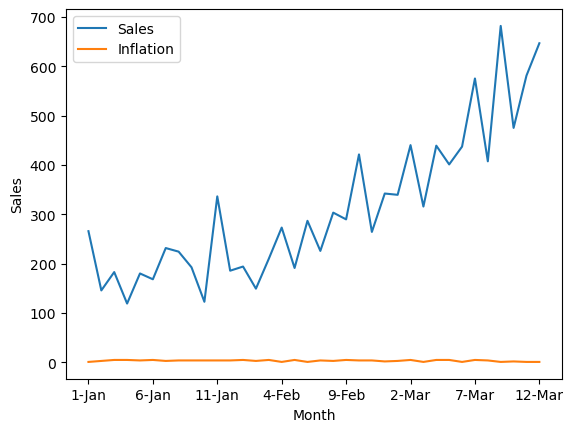

In [ ]:
shampoo.plot()
plt.ylabel("Sales")
plt.show()

In [ ]:
# Read the CSV file into a Series with correct data type conversion
# Load the dataset as a time series
shampoo1 = pd.read_csv("shampoo_with_exog.csv", index_col=[0],parse_dates=True)

# Preview the dataset
print(shampoo1.head())
shampoo1.head()


# Convert the DataFrame to a Series if it has only one column
if len(shampoo1.columns) == 1:
    shampoo1 = shampoo1.squeeze()


# Preview the updated dataset
type(shampoo1)

# index_col is the first index column which is month
# parse_dates=True, means we want month to be a proper date
# squeeze=True, means we make the column into time series


       Sales  Inflation
Month                  
1-Jan  266.0          1
2-Jan  145.9          3
3-Jan  183.1          5
4-Jan  119.3          5
5-Jan  180.3          4


pandas.core.frame.DataFrame

In [ ]:
#check head
shampoo1.head()

,Sales,Inflation
Month,,
1-Jan,266.0,1
2-Jan,145.9,3
3-Jan,183.1,5
4-Jan,119.3,5
5-Jan,180.3,4


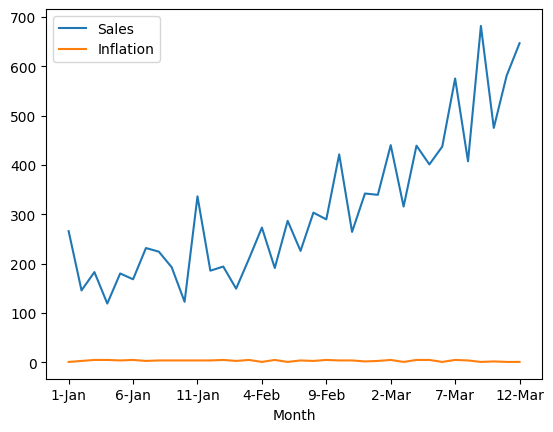

In [ ]:
#visualizing the sales variable with line graph
shampoo1.plot();

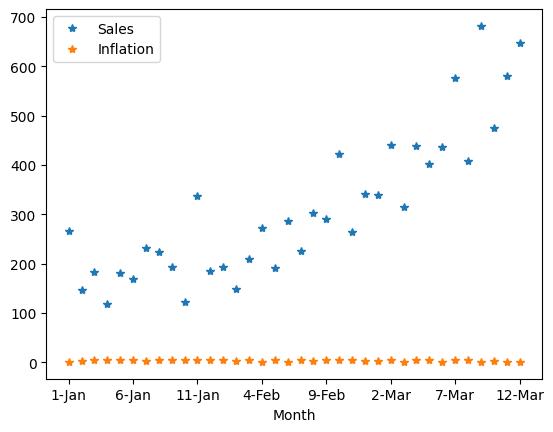

In [ ]:
#visualizing the sales variable with dot graph by introducing the argument style = "k."
shampoo1.plot(style = "*");


In [ ]:
#checking the number of data-points using size property
shampoo1.shape# u can also use shampoo1.size

(36, 2)

In [ ]:
#checking the description using describe method
shampoo1.describe()

,Sales,Inflation
count,36.000000,36.000000
mean,312.600000,3.388889
std,148.937164,1.535816
min,119.300000,1.000000
25%,192.450000,2.000000
50%,280.150000,4.000000
75%,411.100000,5.000000
max,682.000000,5.000000


The value std = 148.937164 refers to the standard deviation of the 'shampoo1' dataset, specifically the 'Sales' variable. Standard deviation is a measure of the amount of variation or dispersion in a set of values. In this context, a standard deviation of 148.937164 indicates that the sales values in the 'shampoo1' dataset have a relatively high amount of variability around the mean. This information can help you understand how spread out the sales values are from the average, providing insights into the volatility or consistency of sales over time.

In [ ]:
#A function to check for stationary
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
  result = adfuller(series)
  print("P value:", result[1])

  if result[1]>0.05:
    print("Is non stationary")
  else:
    print("Is stationary")

In [ ]:
#check sales column
check_stationarity(shampoo["Sales"])

P value: 1.0
Is non stationary


step 1: we need to smoothen the time series by calculting the moving average(MA)

In [ ]:
shampoo1.head()

,Sales,Inflation
Month,,
1-Jan,266.0,1
2-Jan,145.9,3
3-Jan,183.1,5
4-Jan,119.3,5
5-Jan,180.3,4


In [ ]:
#checking the smoothen line
# Calculate the moving average
shampoo1_ma = shampoo1.rolling(window=5, min_periods=2).mean()# mean periods is used if you don't want null values when using window.
shampoo1_ma.head(13)

,Sales,Inflation
Month,,
1-Jan,NaN,NaN
2-Jan,205.950000,2.0
3-Jan,198.333333,3.0
4-Jan,178.575000,3.5
5-Jan,178.920000,3.6
6-Jan,159.420000,4.4
7-Jan,176.600000,4.4
8-Jan,184.880000,4.2
9-Jan,199.580000,4.0


<Figure size 1000x600 with 0 Axes>

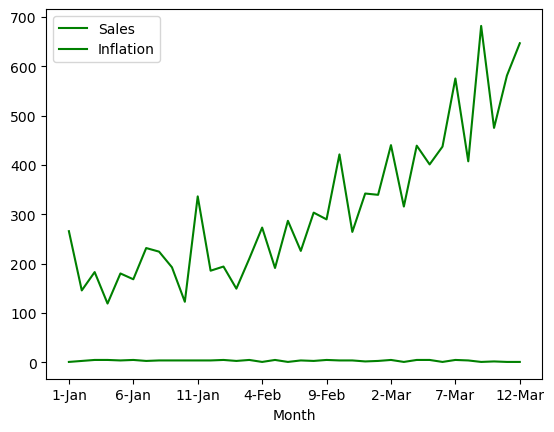

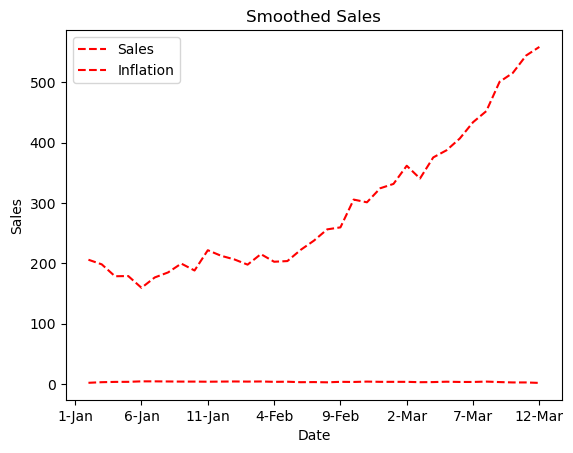

In [ ]:
# Plot both the original sales and the smoothed line on the same graph
plt.figure(figsize=(10, 6))
shampoo1.plot(style='g')
shampoo1_ma.plot(label='Smoothed Sales (MA)', linestyle='--', color="r")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Smoothed Sales')
plt.show()


## Creating the baseline model

Baseline model is a simple model that anyone can come up with.
In time series, this is a model that proves that the current value is a true reflection of previous value. example below


In [ ]:
shampoo1.head()

Jan 2 values are true reflection of Jan 1 values.

Based on this, we use shift method with shifts the datapoints one point down

In [ ]:
##Making the data stationary
shampoo_base = pd.concat([shampoo1, shampoo1.shift(1)], axis=1)
shampoo_base.head()

,Sales,Inflation,Sales,Inflation
Month,,,,
1-Jan,266.0,1,NaN,NaN
2-Jan,145.9,3,266.0,1.0
3-Jan,183.1,5,145.9,3.0
4-Jan,119.3,5,183.1,5.0
5-Jan,180.3,4,119.3,5.0


In [ ]:
#Rename the column names
shampoo_base.columns = ["Sales_actual", "Inflation_actual", "Sales_forecast", "Inflation_forecast"]
shampoo_base.head()

,Sales_actual,Inflation_actual,Sales_forecast,Inflation_forecast
Month,,,,
1-Jan,266.0,1,NaN,NaN
2-Jan,145.9,3,266.0,1.0
3-Jan,183.1,5,145.9,3.0
4-Jan,119.3,5,183.1,5.0
5-Jan,180.3,4,119.3,5.0


In [ ]:
#Drop any null values
shampoo_base.dropna(inplace = True)
shampoo_base.head()

,Sales_actual,Inflation_actual,Sales_forecast,Inflation_forecast
Month,,,,
2-Jan,145.9,3,266.0,1.0
3-Jan,183.1,5,145.9,3.0
4-Jan,119.3,5,183.1,5.0
5-Jan,180.3,4,119.3,5.0
6-Jan,168.5,5,180.3,4.0


In [ ]:
#calculating the error between actual and the forecast
from sklearn.metrics import mean_squared_error
import numpy as np # we import this since we are used in squared error thus will help us in the formula calculation

In [ ]:
shampoo_error = mean_squared_error(shampoo_base.Sales_actual, shampoo_base.Sales_forecast)
shampoo_error

11715.388285714285

this value doesn't reflect any of the values therefore there is a need to get the square of this value.

In [ ]:
#Getting the square
np.sqrt(shampoo_error)

108.23764726616282

Now this is  a true reflection of the values.

## Greating different types of models

the most common used model is ARIMA witch combines autoregressive, integrated and moving average.

In [ ]:
# in arima we have
#ARIMA = (p, d, q) # if parameter p is specified, then it's autoregressive.
#ARIMA = (2,0,0)

#and if
#ARIMA = (0,0, 2)# then it is moving average q

We calculate the above parameters by having ACF(for getting autoregressive p parameters, and PACF for gettingetting MA)

In [ ]:
#import the library
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x400 with 0 Axes>

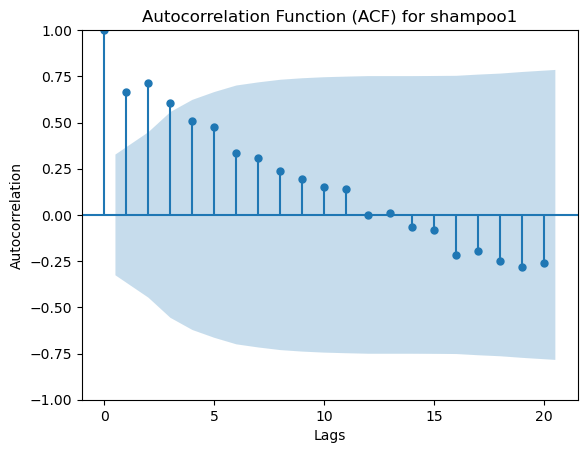

In [ ]:
# Plotting only one graph for ACF
plt.figure(figsize=(10, 4))
plot_acf(shampoo1['Sales'], lags=20)
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (ACF) for shampoo1")
plt.show()

based on the above the p =3

<Figure size 1000x400 with 0 Axes>

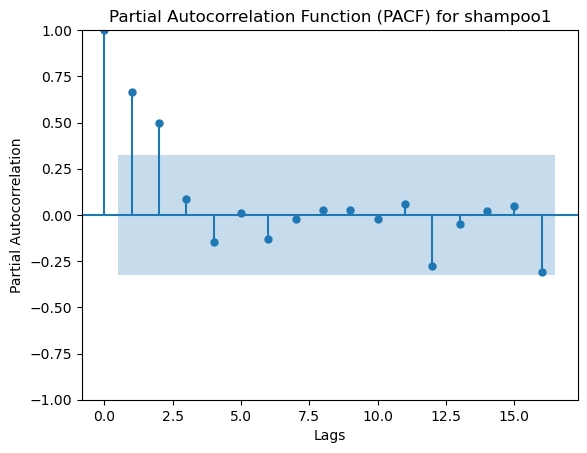

In [ ]:
#Getting moving average q
plt.figure(figsize=(10, 4))
plot_pacf(shampoo1['Sales'])
plt.xlabel("Lags")
plt.ylabel("Partial Autocorrelation")
plt.title("Partial Autocorrelation Function (PACF) for shampoo1")
plt.show()

q = 2. remember we start counting from zero to aplace where the value vanished to shaded area.

we can now get d

d is differencing, you can experiment d btn 0 and 2
d = 0-2

d makes the series seriestationary by removing the seasonality factor

In [ ]:
shampoo1.shape

(36, 2)

In [ ]:
# Creating ARIMA Model
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
#Dividing the data into training and test data
x_train = shampoo1[0:25] # training the model
x_test = shampoo1[25:37] # evalauating the model


In [ ]:
shampoo_train.shape

(25, 2)

In [ ]:
shampoo_test.shape

(11, 2)

In [ ]:
# Defining the ARIMA parameters
p = 3  # Autoregressive parameter
d = 1  # Differencing parameter
q = 2  # Moving average parameter

# Creating the ARIMA model
arima_model = ARIMA(x_train['Sales'], order=(p, d, q))
arima_result = arima_model.fit()

# Printing the summary of the ARIMA model
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   25
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -130.535
Date:                Mon, 28 Jul 2025   AIC                            273.069
Time:                        14:45:46   BIC                            280.138
Sample:                             0   HQIC                           274.944
                                 - 25                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1522      0.343     -0.444      0.657      -0.824       0.520
ar.L2         -0.4743      0.227     -2.094      0.036      -0.918      -0.030
ar.L3         -0.6385      0.259     -2.465      0.0

In [ ]:
# Calculating AIC value
aic_value = arima_result.aic
print("AIC value:", aic_value)

AIC value: 273.0692396089918


The AIC (Akaike Information Criterion) is a measure used to evaluate the goodness of fit of a statistical model. It balances the trade-off between the complexity of the model and its goodness of fit to the data. In the context of time series analysis and the ARIMA model, a lower AIC value indicates a better-fitting model.

The lower the AIC value, the better the model fits the data

Forecasted Shampoo Sales:


<Axes: >

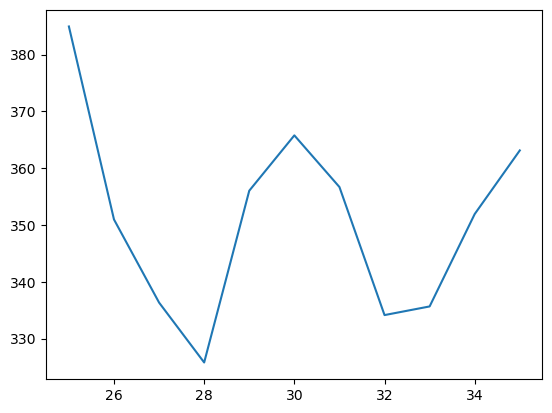

In [ ]:
# Evaluating the model and making forecasts
shampoo_forecast = arima_result.forecast(steps=11)

# Printing the forecasted values
print("Forecasted Shampoo Sales:")
shampoo_forecast.plot()

In [ ]:
mse = np.sqrt(mean_squared_error(x_test['Sales'], shampoo_forecast))
mse

177.72790570286634

Getting the optimal values of model paramaters: you can try the below code.


In [ ]:
p_values = range(0,5)
d_values = range(0,2)
q_values = range(0,5)

In [ ]:
#Getting the optimal params function

import numpy as np
def find_optimal_params(series):
  """
  This function finds the optimal values for p, d, and q parameters for an ARIMA model.

  Args:
    series: A Pandas Series containing the time series data.

  Returns:
    A tuple containing the optimal values for p, d, and q.
  """

  min_aic = np.inf
  optimal_params = None

  for p in p_values:
    for d in d_values:
      for q in q_values:
        try:
          model = ARIMA(series, order=(p, d, q))
          result = model.fit()
          if result.aic < min_aic:
            min_aic = result.aic
            optimal_params = (p, d, q)
        except:
          continue

  return optimal_params


In [ ]:
#show the optimal params

optimal_params = find_optimal_params(shampoo1)
print("Optimal parameters:", optimal_params)


Optimal parameters: None


In [ ]:
# create sarima model

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the model
sarima_model = SARIMAX(shampoo_train['Sales'], order=(3, 1, 2), seasonal_order=(3, 1, 2, 12))

# Fit the model
sarima_result = sarima_model.fit()

# Make predictions
sarima_forecast = sarima_result.forecast(steps=11)

# Print the forecasted values
print("Forecasted Shampoo Sales:")
print(sarima_forecast)

Forecasted Shampoo Sales:
25    404.120301
26    263.190664
27    381.990923
28    262.992740
29    429.760428
30    316.448811
31    479.367884
32    282.346459
33    391.992386
34    419.383524
35    447.652142
Name: predicted_mean, dtype: float64


In [ ]:
sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   25
Model:             SARIMAX(3, 1, 2)x(3, 1, 2, 12)   Log Likelihood                 -71.198
Date:                            Mon, 28 Jul 2025   AIC                            164.396
Time:                                    14:55:16   BIC                            169.729
Sample:                                         0   HQIC                           162.421
                                             - 25                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6242      5.511     -0.113      0.910     -11.425      10.176
ar.L2         -0.5113     11.488     -0.045      0.965     -23.028      22.005
ar.L3         -0.7993      8.934     -0.089      0.929     -18.310      16.711
ma.L1         -0.9048      6.398     -0.141      0.888     -13.444      11.635
ma.L2          0.6746      5.586      0.121      0.904     -10.274      11.623
ar.S.L12      -0.8450     30.729     -0.027      0.978     -61.072      59.382
ar.S.L24       0.9858      5.236      0.188      0.851      -9.277      11.249
ar.S.L36       0.8469     35.654      0.024      0.981     -69.033      70.727
ma.S.L12      -0.0877      7.575     -0.012      0.991     -14.934      14.759
ma.S.L24      -0.7836     43.006     -0.018      0.985     -85.075      83.507
sigma2       534.4169      0.058   9200.925      0.000     534.303     534.531
===================================================================================
Ljung-Box (L1) (Q):                   1.87   Jarque-Bera (JB):                 0.40
Prob(Q):                              0.17   Prob(JB):                         0.82
Heteroskedasticity (H):               2.58   Skew:                             0.43
Prob(H) (two-sided):                  0.38   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.58e+22. Standard errors may be unstable.
"""

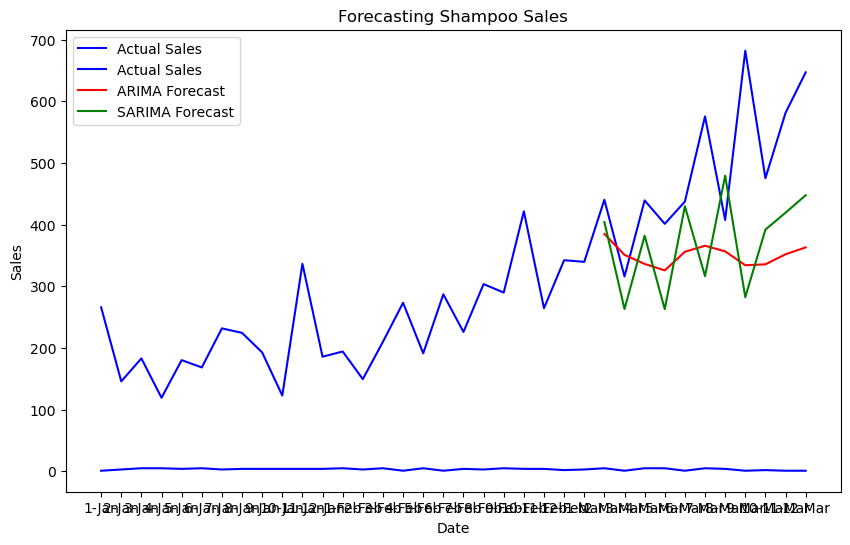

In [ ]:
#visualize the forecasting

import matplotlib.pyplot as plt
# Plot the actual and forecasted values
plt.figure(figsize=(10, 6))
plt.plot(shampoo1, label="Actual Sales", color="blue")
plt.plot(shampoo_forecast, label="ARIMA Forecast", color="red")
plt.plot(sarima_forecast, label="SARIMA Forecast", color="green")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Forecasting Shampoo Sales")
plt.legend()
plt.show()


Do Research on these  models
1. fb prophet
2. hollywinter model
3. LSTM (RNN)


In [ ]:
# refer to the shared geeks for geeks article and come up withn fb prophet model. Try the on other datasets.

url = ("https://raw.githubusercontent.com/rahulhegde99"
      "/Time-Series-Analysis-and-Forecasting-of-Air-Passengers"
        "/master/airpassengers.csv")
data = pd.read_csv(url)
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
